In [101]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [102]:
#carregar imagens
imagem_cozinheiro_bgr = cv2.imread('data/cozinheiro.png')
imagem_cozinheiro = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2RGB)
imagem_raio_x_bgr = cv2.imread('data/raiox.png')
imagem_raio_x = cv2.cvtColor(imagem_raio_x_bgr, cv2.COLOR_BGR2RGB)
imagem_borrada_bgr = cv2.imread('data/borrada.png')
imagem_borrada = cv2.cvtColor(imagem_borrada_bgr, cv2.COLOR_BGR2RGB)


In [103]:
# funcao de filtro da media
def filtro_media(img, tamanho_kernel=3):
    img = img.astype(np.float64)
    h, w, c = img.shape
    out = np.zeros_like(img)
    margem = tamanho_kernel // 2

    img_pad = np.pad(img, ((margem, margem), (margem, margem), (0, 0)), mode='edge')

    for i in range(h):
        for j in range(w):
            janela = img_pad[i:i + tamanho_kernel, j:j + tamanho_kernel, :]
            media = janela.mean(axis=(0, 1))
            out[i, j] = media

    return out.astype(np.uint8)

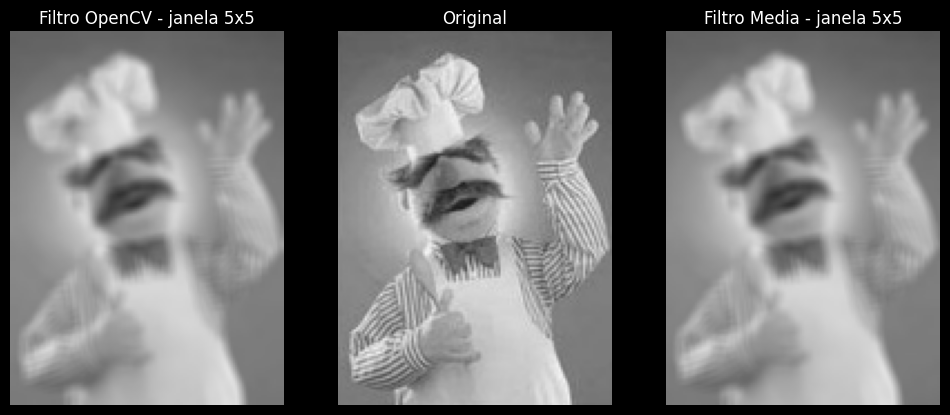

In [104]:
#comparacao com o filtro da biblioteca
janela = 5
img_filtro_cv = cv2.blur(imagem_cozinheiro, (janela, janela))
imagem_filtro_media = filtro_media(imagem_cozinheiro, janela)
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(img_filtro_cv)
plt.title(f'Filtro OpenCV - janela {janela}x{janela}')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(imagem_cozinheiro)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(imagem_filtro_media)
plt.title(f'Filtro Media - janela {janela}x{janela}')
plt.axis('off')
plt.show()

In [105]:
# funcao de filtro da mediana
def filtro_mediana(img, tamanho_kernel=3):
    img = img.astype(np.float64)
    h, w, c = img.shape
    out = np.zeros_like(img)
    margem = tamanho_kernel // 2
    img_pad = np.pad(img, ((margem, margem), (margem, margem), (0, 0)), mode='edge')

    for i in range(h):
        for j in range(w):
            janela = img_pad[i:i + tamanho_kernel, j:j + tamanho_kernel, :]
            mediana = np.median(janela, axis=(0, 1))
            out[i, j] = mediana

    return np.clip(out, 0, 255, ).astype(np.uint8)

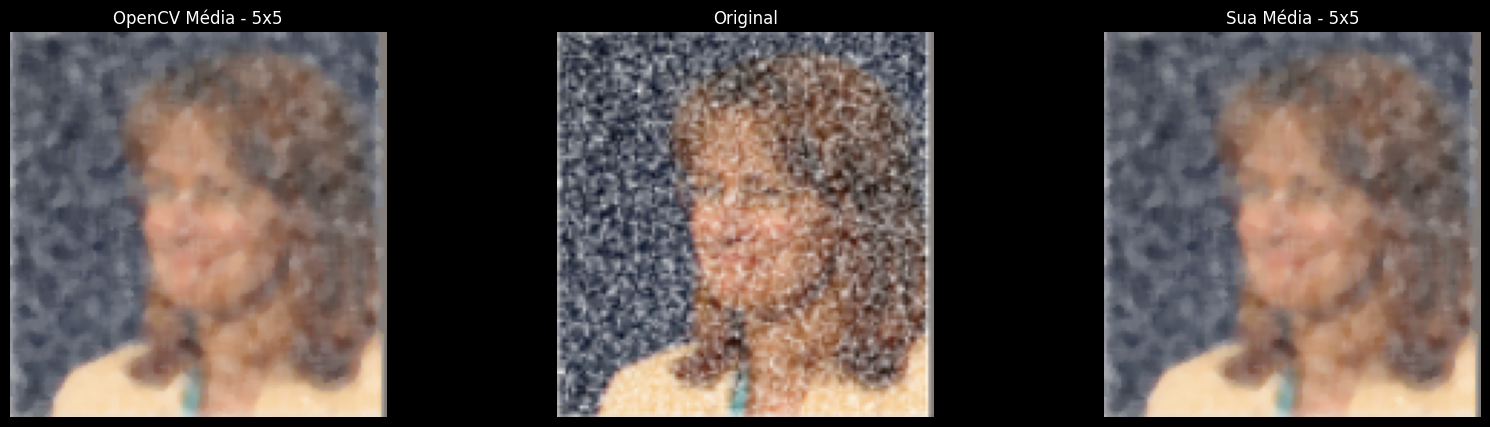

In [106]:
img_media_cv = cv2.medianBlur(imagem_borrada, janela)
img_mediana_manual = filtro_mediana(imagem_borrada, janela)

plt.figure(figsize=(20, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_media_cv)
plt.title(f'OpenCV Média - {janela}x{janela}')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(imagem_borrada)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_mediana_manual)
plt.title(f'Sua Média - {janela}x{janela}')
plt.axis('off')

plt.show()

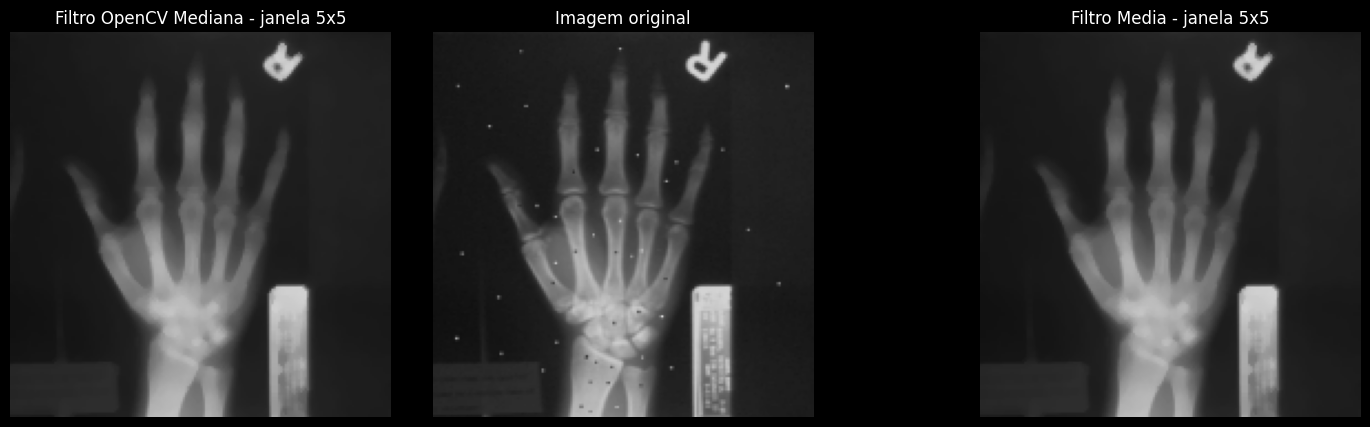

In [108]:
janela = 5
imagem_filtro_filtro_mediax = filtro_mediana(imagem_raio_x, janela)
img_mediana_cv = cv2.medianBlur(imagem_raio_x, janela)
plt.figure(figsize=(20, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_mediana_cv)
plt.title(f'Filtro OpenCV Mediana - janela {janela}x{janela}')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(imagem_raio_x)
plt.title('Imagem original')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(imagem_filtro_filtro_mediax)
plt.title(f'Filtro Media - janela {janela}x{janela}')
plt.axis('off')
plt.show()